# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/complaints_processed.csv')
df.head(10)

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
5,5,credit_reporting,payment history missing credit report made mis...
6,6,credit_reporting,va date complaint experian credit bureau invol...
7,7,credit_reporting,account reported abbreviated name full name se...
8,8,credit_reporting,account reported abbreviated name full name se...
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...


In [3]:
df.tail(10)

,Unnamed: 0,product,narrative
162411,162411,retail_banking,zelle suspended account without cause banking ...
162412,162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,162414,debt_collection,zuntafi sent notice willing settle defaulted s...
162415,162415,debt_collection,name
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name
162420,162420,credit_reporting,name


In [4]:
print(f'Size of dataframe: {df.shape}')
print(f'Datatype of columns:\n {df.dtypes}')
print(f'product category count:\n {df['product'].value_counts()}')
print(f'Number of Null values in dataframe:\n {df.isnull().sum()}')

Size of dataframe: (162421, 3)
Datatype of columns:
 Unnamed: 0     int64
product       object
narrative     object
dtype: object
product category count:
 product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64
Number of Null values in dataframe:
 Unnamed: 0     0
product        0
narrative     10
dtype: int64


In [5]:
df = df.drop_duplicates()
df = df.drop(['Unnamed: 0'], axis=1)
df = df[df['narrative'] != 'name']
df = df.dropna()
df.isnull().sum()

,0
product,0
narrative,0


In [6]:
df.tail()

,product,narrative
162410,credit_reporting,zales comenity bank closed sold account report...
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,debt_collection,zuntafi sent notice willing settle defaulted s...


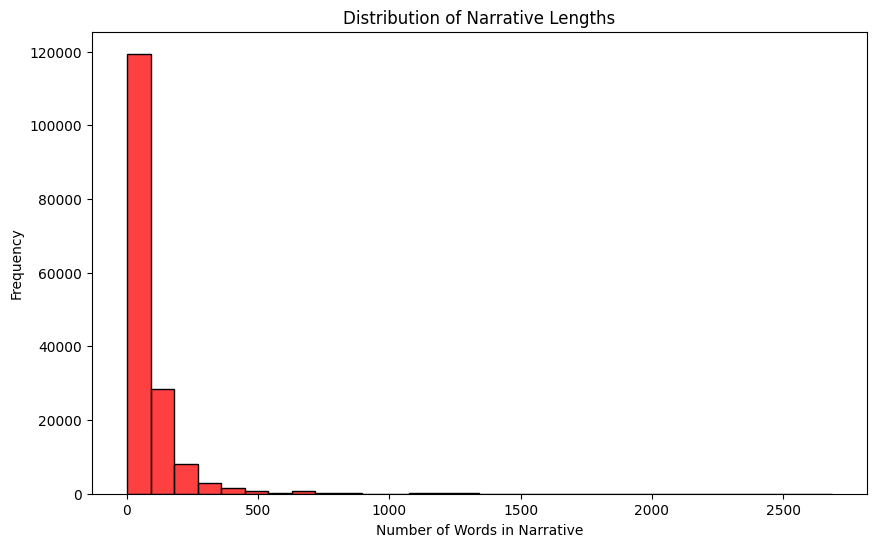

In [7]:
df['narrative_length'] = df['narrative'].apply(lambda x: len(x.split()))
plt.figure(figsize = (10, 6))
sns.histplot(df['narrative_length'], bins = 30, color = 'red')
plt.title('Distribution of Narrative Lengths')
plt.xlabel('Number of Words in Narrative')
plt.ylabel('Frequency')
plt.show()

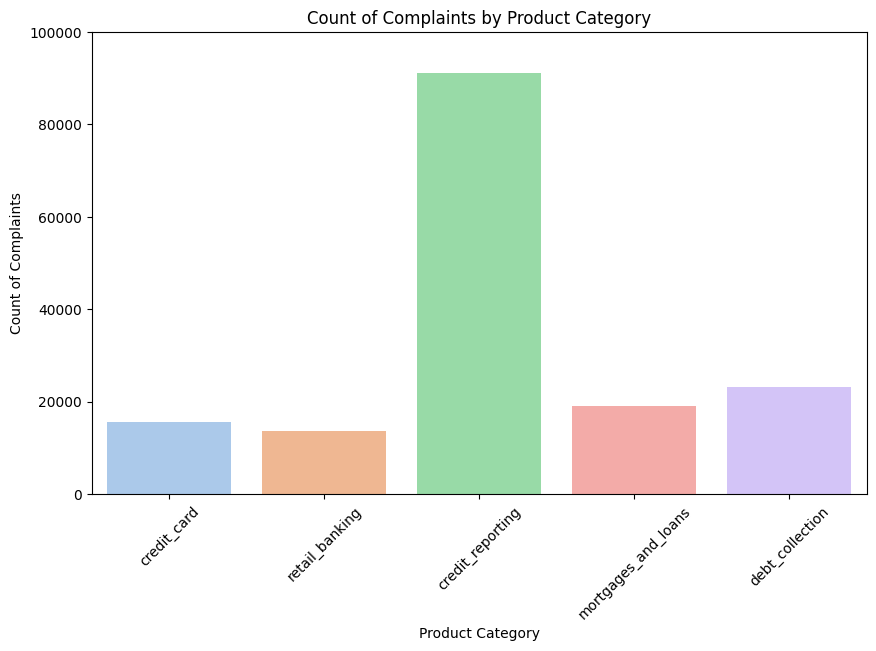

In [8]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'product', data = df, palette = 'pastel')
plt.title('Count of Complaints by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count of Complaints')
plt.xticks(rotation = 45)
plt.ylim(0, 100000)
plt.show()

Dataframe is <b>imbalanced</b>. Improving the balance of the dataframe can improve <b>accuracy</b>.

In [9]:
from sklearn.model_selection import train_test_split
df = df.drop(['narrative_length'], axis=1)
train_data, test_data = train_test_split(df, test_size = 0.20)
train_data.shape, test_data.shape

((129924, 2), (32481, 2))

* credit_card, debt_collection, mortgages_and_loans, retail_banking columns consist of <b>very few values</b>. So, the values in these columns will be increased using <b>random oversampling</b>.
* Oversampling is done in train set because this will prevent <b>data leakage</b> to test set.  

# 3. Random undersampling

In [10]:
df1 = np.random.choice(train_data[train_data['product']=='credit_card'].index,size = 7000,replace=False)
df2 = np.random.choice(train_data[train_data['product']=='debt_collection'].index,size = 7000,replace=False)
df3 = np.random.choice(train_data[train_data['product']=='mortgages_and_loans'].index,size = 7000,replace=False)
df4 = np.random.choice(train_data[train_data['product']=='retail_banking'].index,size=7000,replace=False)
concat_df = np.concatenate((df1, df2, df3, df4))
len(concat_df)


28000

In [11]:
df_replicate = train_data[train_data.index.isin(concat_df)]
df_replicate

,product,narrative
51074,debt_collection,affected sick left message customer service nu...
54524,debt_collection,disputed charge many time navy federal dont de...
15028,credit_card,dear sir madam year opened paypal mastercard a...
114327,mortgages_and_loans,told via email would returned via bank america...
26973,credit_card,always pay time following receipt paper statem...
...,...,...
24488,retail_banking,hello opened account chase bank funded account...
69044,credit_card,purchased clearance mattress mattress firm off...
136277,debt_collection,attempt collect debt illegal never opened acco...
97346,retail_banking,card blocked called verified information bank ...


In [12]:
train_data = pd.concat([train_data, df_replicate])
train_data['product'].value_counts()

,count
product,
credit_reporting,73043
debt_collection,25386
mortgages_and_loans,22208
credit_card,19421
retail_banking,17866


## Data Preprocessing

In [13]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [14]:
def preprocess_text(df):
    df['narrative'] = df['narrative'].str.lower()
    df['narrative'] = df['narrative'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
    df['narrative'] = df['narrative'].apply(lambda x: x.split())
    df['narrative'] = df['narrative'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x if word not in stop_words])

    return df

train_data = preprocess_text(train_data)
test_data = preprocess_text(test_data)
train_data.head()

,product,narrative
29297,credit_reporting,"[victim, identity, notified, collection, credi..."
51074,debt_collection,"[affected, sick, left, message, customer, serv..."
159400,credit_reporting,"[reporting, equifax, day, late, partial, accou..."
106770,credit_reporting,"[applied, credit, line, increase, card, notifi..."
50050,credit_reporting,"[asked, account, validated, multiple, time, ev..."


# 6. Tokenizing Sentences and Fixing Sentence Length

In [15]:
max_words = 2500
max_sequence_length = 170
embedding_dim = 128

from collections import Counter
all_tokens = [token for sentence in train_data.narrative for token in sentence]
counter = Counter(all_tokens)
most_common = counter.most_common(max_words - 2)  # reserve 2 for <pad> and <unk>

vocab = {'<pad>': 0, '<unk>': 1} # Build vocab: word -> index
for i, (word, _) in enumerate(most_common, start=2):
    vocab[word] = i

inv_vocab = {i: w for w, i in vocab.items()} # Reverse vocab for debugging (optional)

# Encoding function: tokens -> indices
def encode(tokens):
    indices = []
    for t in tokens:
        idx = vocab.get(t, vocab['<unk>'])
        if idx < 0 or idx >= len(vocab):
            idx = vocab['<unk>']
        indices.append(idx)
    return torch.tensor(indices, dtype=torch.long)


train_sequences = [encode(tokens) for tokens in train_data.narrative]
test_sequences  = [encode(tokens) for tokens in test_data.narrative]


#  Padding sequences to fixed length (max_sequence_length) with <pad> token
def pad_fixed(seq, max_len=max_sequence_length):
    seq = seq[:max_len]  # truncate if too long
    padding_len = max_len - len(seq)
    if padding_len > 0:
        padding = torch.full((padding_len,), vocab['<pad>'], dtype=torch.long)
        seq = torch.cat([seq, padding])
    return seq

train_padded = torch.stack([pad_fixed(seq) for seq in train_sequences])
test_padded  = torch.stack([pad_fixed(seq) for seq in test_sequences])

print("Train shape:", train_padded.shape)  # (num_samples, max_sequence_length)
print("Test shape:", test_padded.shape)

Train shape: torch.Size([157924, 170])
Test shape: torch.Size([32481, 170])


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [17]:
le = LabelEncoder()
train_data['product'] = le.fit_transform(train_data['product'])
test_data['product'] = le.transform(test_data['product'])
train_labels = torch.tensor(train_data['product'].values, dtype=torch.long)
test_labels = torch.tensor(test_data['product'].values, dtype=torch.long)

In [18]:
class LSTMClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab['<pad>'])
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        logits = self.fc(hidden[-1])
        return logits

hidden_dim = 64
num_classes = len(le.classes_) # Get the number of unique classes from LabelEncoder
model = LSTMClassifier(embedding_dim, hidden_dim, len(vocab), num_classes) # Pass num_classes as output_dim
model.to(device)

LSTMClassifier(
  (embedding): Embedding(2500, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)

In [19]:
train_dataset = TensorDataset(train_padded, train_labels)
test_dataset = TensorDataset(test_padded, test_labels)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [21]:
epochs = 10

for epoch in range(epochs):
    model.train()
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_logits = model(x_batch)
        loss = loss_fn(y_logits, y_batch)
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
        acc = accuracy_fn(y_batch, y_pred)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
      y_logits = model(x_batch)
      y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
      test_loss = loss_fn(y_logits, y_batch)
      test_acc = accuracy_fn(y_batch, y_pred)
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.89584, Acc: 50.00% | Test Loss: 0.86075, Test Acc: 50.00%
Epoch: 1 | Loss: 0.59479, Acc: 75.00% | Test Loss: 0.52189, Test Acc: 75.00%
Epoch: 2 | Loss: 0.12972, Acc: 100.00% | Test Loss: 0.12061, Test Acc: 100.00%
Epoch: 3 | Loss: 0.03474, Acc: 100.00% | Test Loss: 0.02626, Test Acc: 100.00%
Epoch: 4 | Loss: 1.31052, Acc: 50.00% | Test Loss: 0.97882, Test Acc: 50.00%
Epoch: 5 | Loss: 0.01692, Acc: 100.00% | Test Loss: 0.01675, Test Acc: 100.00%
Epoch: 6 | Loss: 0.33659, Acc: 75.00% | Test Loss: 0.23162, Test Acc: 100.00%
Epoch: 7 | Loss: 0.10784, Acc: 100.00% | Test Loss: 0.08721, Test Acc: 100.00%
Epoch: 8 | Loss: 0.05699, Acc: 100.00% | Test Loss: 0.03775, Test Acc: 100.00%
Epoch: 9 | Loss: 0.19132, Acc: 75.00% | Test Loss: 0.02439, Test Acc: 100.00%
Epoch: 10 | Loss: 0.03798, Acc: 100.00% | Test Loss: 0.02526, Test Acc: 100.00%
Epoch: 11 | Loss: 0.05702, Acc: 100.00% | Test Loss: 0.03180, Test Acc: 100.00%
Epoch: 12 | Loss: 0.02162, Acc: 100.00% | Test Loss: 0.018